# Padas的缺失值处理函数

## pandas中的缺失值

pandas使用浮点值NaN（Not a Number）表示缺失数据，使用NA（Not Available）表示缺失值。可以通过isnull()、isna()或notnull()、notna()方法判断某个值是否为缺失值。
Nan通常表示一个无效的或未定义的数字值，是浮点数的一种特殊取值，用于表示那些不能表示为正常数字的情况，如 0/0、∞-∞等数学运算的结果。nan与任何值（包括它自身）进行比较的结果都为False。例如在 Python 中，nan == nan返回False。
NA一般用于表示数据不可用或缺失的情况，它的含义更侧重于数据在某种上下文中是缺失或不存在的，不一定特指数字类型的缺失。
na和nan都用于表示缺失值，但nan更强调是数值计算中的特殊值，而na更强调数据的可用性或存在性。

In [2]:
import pandas as pd
import numpy as np

In [3]:
s=pd.Series([np.nan,None,pd.NA])

In [4]:
s.isnull

<bound method Series.isnull of 0     NaN
1    None
2    <NA>
dtype: object>

## 加载数据中包含缺失值

In [5]:
df = pd.read_csv('./datas/weather_withna.csv')

In [6]:
df.tail(5)

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,NaN,NaN,NaN,NaN,NaN
1457,2015-12-28,NaN,NaN,NaN,NaN,NaN
1458,2015-12-29,NaN,NaN,NaN,NaN,NaN
1459,2015-12-30,NaN,NaN,NaN,NaN,NaN
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [7]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1158.000000,1158.000000,1158.000000,1158.000000
mean,3.052332,15.851468,7.877202,3.242055
std,6.359886,7.244054,5.025664,1.477244
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.000000,4.400000,2.200000
50%,0.000000,14.400000,7.800000,3.000000
75%,3.000000,21.100000,11.700000,4.100000
max,54.100000,35.600000,18.300000,9.500000


可以通过keep_default_na参数设置是否将空白值设置为缺失值。

In [11]:
df

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,NaN,NaN,NaN,NaN,NaN
1457,2015-12-28,NaN,NaN,NaN,NaN,NaN
1458,2015-12-29,NaN,NaN,NaN,NaN,NaN
1459,2015-12-30,NaN,NaN,NaN,NaN,NaN


In [12]:
df=pd.read_csv('./datas/weather_withna.csv',keep_default_na=False)

In [13]:
df.tail(5)

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,,,,,
1457,2015-12-28,,,,,
1458,2015-12-29,,,,,
1459,2015-12-30,,,,,
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


## 查看缺失值

- 通过isnull()查看缺失值数量

In [15]:
df=pd.read_csv('./datas/weather_withna.csv')

In [16]:
df.isnull().sum()

date               0
precipitation    303
temp_max         303
temp_min         303
wind             303
weather          303
dtype: int64

- 通过missingno条形图展示缺失值

先安装missingno包：pip install missingno

<Axes: >

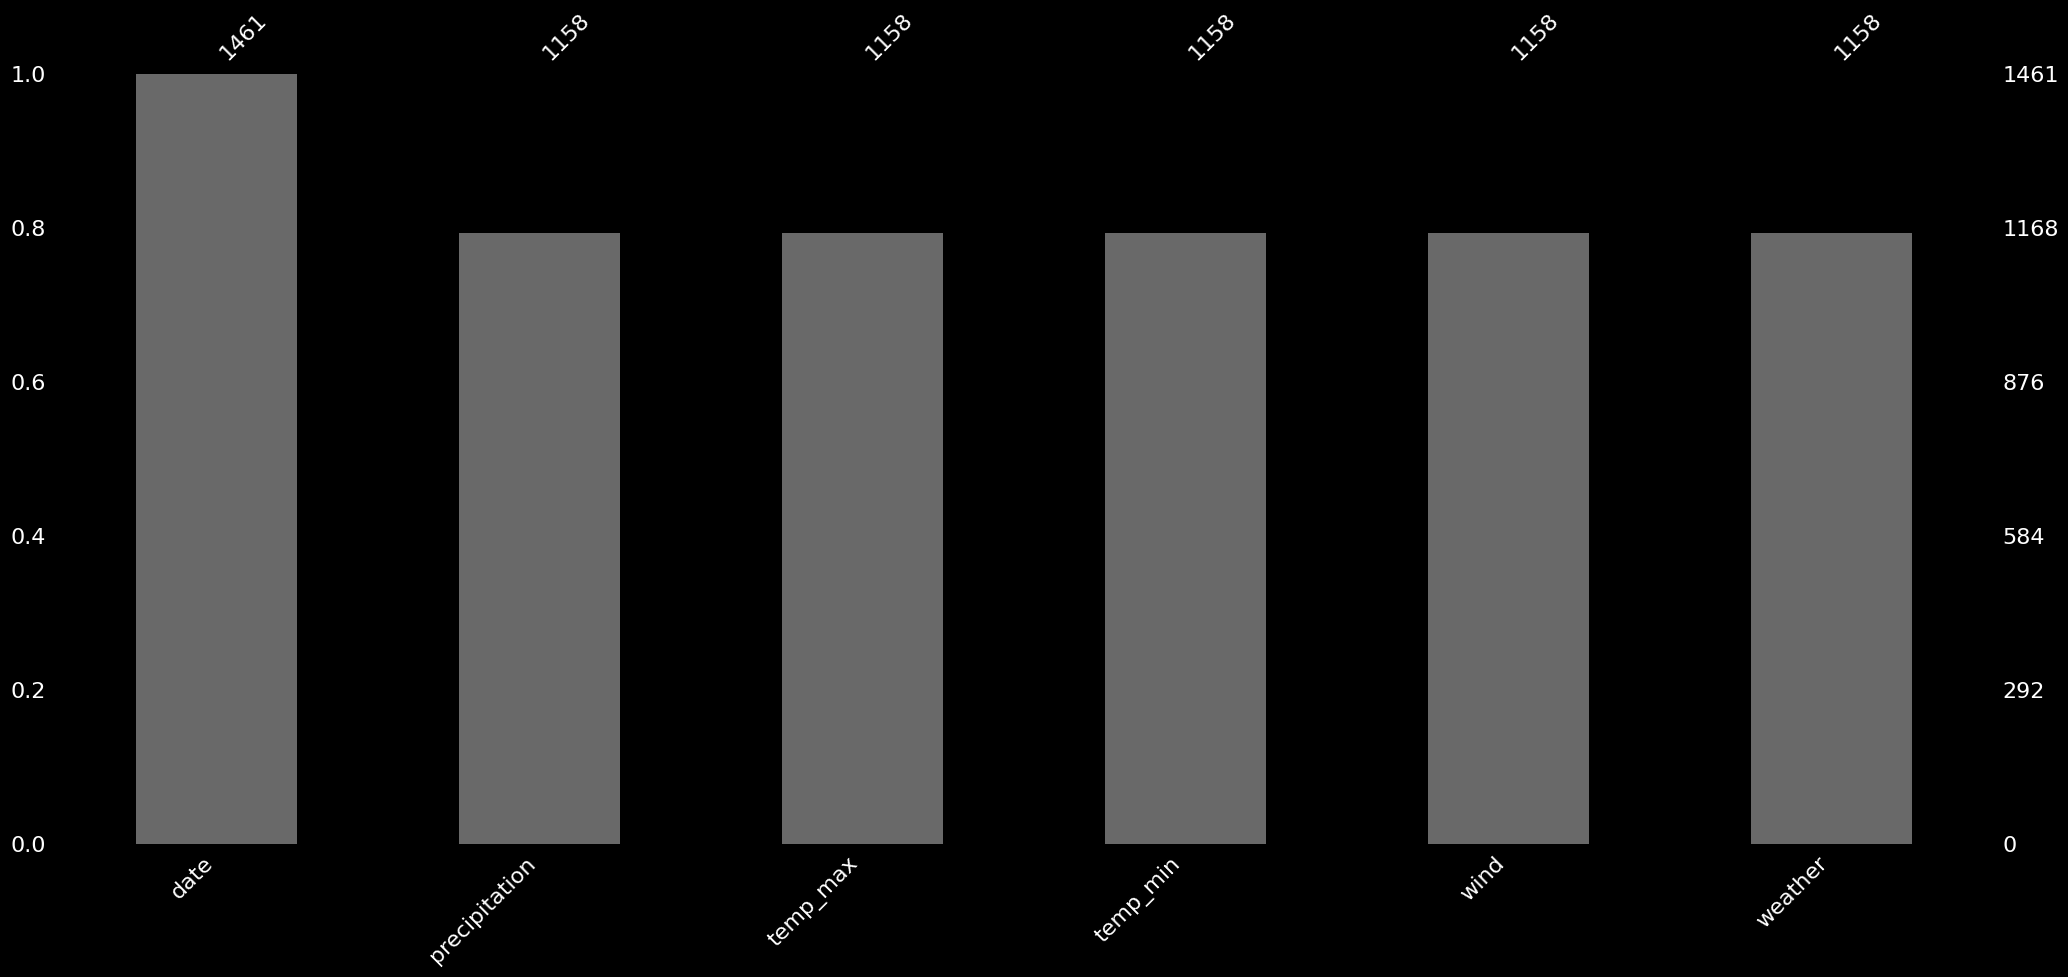

In [19]:
import missingno as msno
df = pd.read_csv("./datas/weather_withna.csv")
msno.bar(df)

- 通过热力图查看缺失值的相关性

missingno绘制的热力图能够展示数据集中不同列的缺失值之间的相关性。这里的相关性体现的是当某一列出现缺失值时，其他列出现缺失值的可能性。如果两个列的缺失值呈现正相关，意味着当其中一列有缺失值时，另一列也很可能有缺失值；若为负相关，则表示当一列有缺失值时，另一列更倾向于没有缺失值。
颜色与数值：热力图中的颜色和数值反映了列之间缺失值的相关性。接近 1 表示正相关，接近 -1 表示负相关，接近 0 则表示缺失值之间没有明显的关联。
示例说明：假如 A 列和 B 列在热力图中对应区域颜色较深且数值接近 1，这就表明当 A 列出现缺失值时，B 列也很可能出现缺失值；若数值接近 -1，情况则相反。

<Axes: >

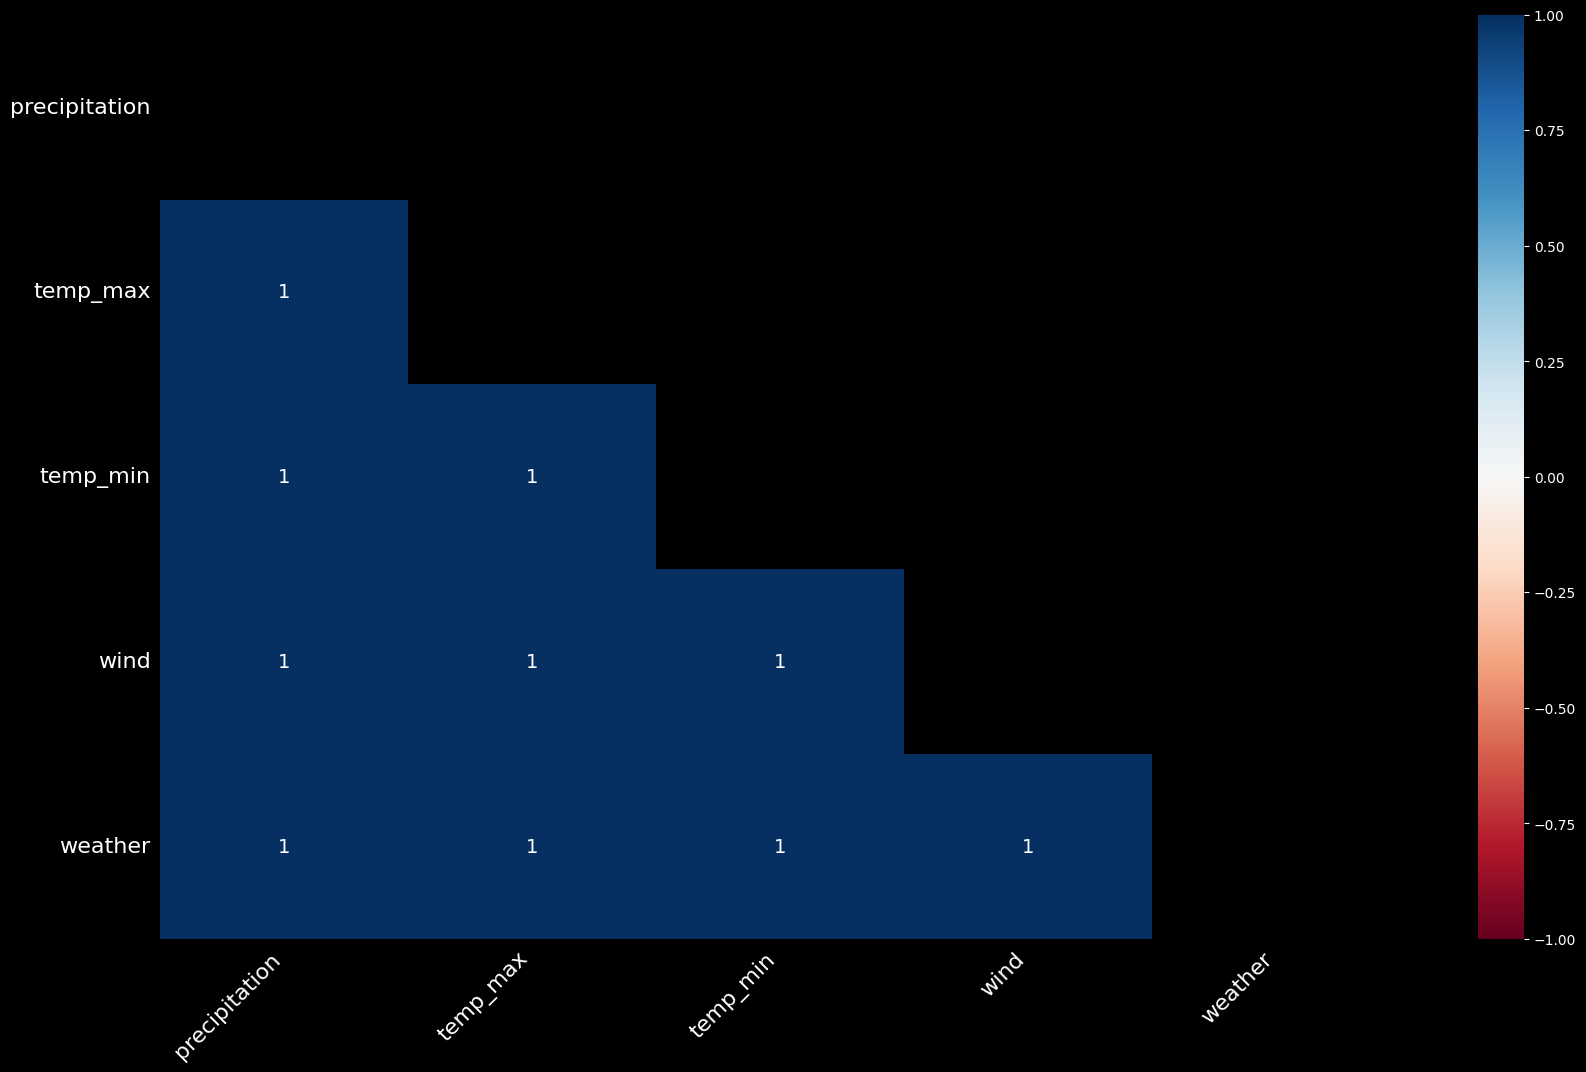

In [20]:
msno.heatmap(df)

## 剔除缺失值

通过dropna()方法来剔除缺失值。

1）Series剔除缺失值

In [21]:
s = pd.Series([1, pd.NA, None])
s

0       1
1    <NA>
2    None
dtype: object

In [22]:
s.dropna()

0    1
dtype: object

2）DataFrame剔除缺失值

In [23]:
df = pd.DataFrame([[1, pd.NA, 2], [2, 3, 5], [pd.NA, 4, 6]])
df

,0,1,2
0,1,<NA>,2
1,2,3,5
2,<NA>,4,6


In [24]:
df.dropna()

,0,1,2
1,2,3,5


可以设置按不同的坐标轴剔除缺失值，比如axis=1（或 axis='columns'）会剔除任何包含缺失值的整列数据。

In [25]:
df = pd.DataFrame([[1, pd.NA, 2], [2, 3, 5], [pd.NA, 4, 6]])

In [26]:
df

,0,1,2
0,1,<NA>,2
1,2,3,5
2,<NA>,4,6


In [27]:
df.dropna(axis=1)

,2
0,2
1,5
2,6


有时只需要剔除全部是缺失值的行或列，或者绝大多数是缺失值的行或列。这些需求可以通过设置how或thresh参数来满足，它们可以设置剔除行或列缺失值的数量阈值。

In [28]:
df = pd.DataFrame([[1, pd.NA, 2], [pd.NA, pd.NA, 5], [pd.NA, pd.NA, pd.NA]])

In [29]:
df.dropna(how='all') ## 如果所有值都是缺失值,则删除这一行

,0,1,2
0,1,<NA>,2
1,<NA>,<NA>,5


In [30]:
print(df.dropna(thresh=2))

   0     1  2
0  1  <NA>  2


可以通过设置subset参数来设置某一列有缺失值则进行剔除。

In [31]:
df = pd.DataFrame([[1, pd.NA, 2], [pd.NA, pd.NA, 5], [pd.NA, pd.NA, pd.NA]])
print(df)

print(df.dropna(subset=[0]))

      0     1     2
0     1  <NA>     2
1  <NA>  <NA>     5
2  <NA>  <NA>  <NA>
   0     1  2
0  1  <NA>  2


## 填充缺失值

1）使用固定值填充
通过fillna()方法，传入值或字典进行填充。

In [33]:
df = pd.read_csv("./datas/weather_withna.csv")

In [34]:
df.fillna(0).tail()# 使用固定值填充

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,0.0,0.0,0.0,0.0,0
1457,2015-12-28,0.0,0.0,0.0,0.0,0
1458,2015-12-29,0.0,0.0,0.0,0.0,0
1459,2015-12-30,0.0,0.0,0.0,0.0,0
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [35]:
df.fillna({"temp_max": 60, "temp_min": -60}).tail() # 使用字典来填充

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,NaN,60.0,-60.0,NaN,NaN
1457,2015-12-28,NaN,60.0,-60.0,NaN,NaN
1458,2015-12-29,NaN,60.0,-60.0,NaN,NaN
1459,2015-12-30,NaN,60.0,-60.0,NaN,NaN
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


2）使用统计值填充
通过fillna()方法，传入统计后的值进行填充。

In [36]:
df.fillna(df[["precipitation", "temp_max", "temp_min", "wind"]].mean()).tail() # 使用平均值填充

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,3.052332,15.851468,7.877202,3.242055,NaN
1457,2015-12-28,3.052332,15.851468,7.877202,3.242055,NaN
1458,2015-12-29,3.052332,15.851468,7.877202,3.242055,NaN
1459,2015-12-30,3.052332,15.851468,7.877202,3.242055,NaN
1460,2015-12-31,20.600000,12.200000,5.000000,3.800000,rain


3）使用前后的有效值填充
通过ffill()或bfill()方法使用前面或后面的有效值填充。

In [37]:
df.ffill().tail() #important 使用前面的有效值填充 forhead fill 简写ffill

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,0.0,11.1,4.4,4.8,sun
1457,2015-12-28,0.0,11.1,4.4,4.8,sun
1458,2015-12-29,0.0,11.1,4.4,4.8,sun
1459,2015-12-30,0.0,11.1,4.4,4.8,sun
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [38]:
print(df.bfill().tail()) #important 使用后面的有效值填充 backend fill 缩写

            date  precipitation  temp_max  temp_min  wind weather
1456  2015-12-27           20.6      12.2       5.0   3.8    rain
1457  2015-12-28           20.6      12.2       5.0   3.8    rain
1458  2015-12-29           20.6      12.2       5.0   3.8    rain
1459  2015-12-30           20.6      12.2       5.0   3.8    rain
1460  2015-12-31           20.6      12.2       5.0   3.8    rain


4）通过线性插值填充
通过interpolate()方法进行线性插值填充。线性插值操作，就是用于在已知数据点之间估算未知数据点的值。interpolate 方法支持多种插值方法，可通过 method 参数指定，常见的方法有：
'linear'：线性插值，基于两点之间的直线来估算缺失值，适用于数据呈线性变化的情况。
'time'：适用于时间序列数据，会考虑时间间隔进行插值。
'polynomial'：多项式插值，通过拟合多项式曲线来估算缺失值，可通过 order 参数指定多项式的阶数。

In [39]:
# 创建包含缺失值的 Series
s = pd.Series([1, np.nan, 3, 4, np.nan, 6])
# 使用默认的线性插值方法填充缺失值
s_interpolated = s.interpolate()
print(s_interpolated)

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
5    6.0
dtype: float64
